In [1]:
from pathlib import Path
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
def get_spark():
    return SparkSession.builder \
        .appName('TCC - Testes') \
        .getOrCreate()

spark = get_spark()

In [15]:
base_path = "../data/criminalidade/curated/veiculos_setor_parquet"

df = (
    spark.read
    .option("basePath", base_path)
    .option("mergeSchema", "true")
    .parquet(f"{base_path}/ano_trimestre=*")
)

df_ocorrencias = df.withColumn(
    "ano",
    F.regexp_extract(
        F.col("ano_trimestre"),
        r"(\d{4})",
        1
    ).cast("int")
)

df_ocorrencias = (
    df_ocorrencias
    .filter(
        F.col("ano").cast("int").between(2020, 2025)
    )
)

df_ocorrencias = df_ocorrencias.filter(df_ocorrencias.SJ_CD_SETOR.isNotNull())
# df_ocorrencias.printSchema()
df_ocorrencias.show(5, False)

+------------+--------------------+--------------------+--------------+------+-------+------+----------------------+-------------------+------------------------+-------------------+------------------+---------------+----------------------+-------------------+----------------------+------------+--------------+-----------+----------------+-------------+--------------------+------------------+-----------------+-------+-------------------+---------------------------------+-----------------+-----------------+-----------------+------------+------------------------+------------------+--------------------+--------------+----------+-------------+-----------------+---------------+---------------+-------------------+-----------+-----------------+-----------------+----------------------------+----------------------+-------------------+-------------+--------+--------+-----------+---------------+-----------+---------+----------+-----------------+------------+------------+--------+---------+---------

In [16]:
df_censo_final = spark.read.parquet('../data/censo/final/processed/setor')
df_censo = df_censo_final.filter(df_censo_final.nm_mun == 'São Paulo')
# df_censo.printSchema()
df_censo.show(5, False)

+---------------+---------+---------+-----------+-----------+-----------+-------+--------------------+-------+---------+---------+----------+-------------+----------------------------------+--------------------------------+----------------------+--------------------+----------------------+-------------------+--------------------------------------------+------------------+------------------+---------------------+-------------------+-----------+----------+--------------------+-------------------+-------------------+----------------------------+---------------------------------------+-----------------------------------------+-------------------------------------------+------------------------------------+-----------------+-----------------+--------------------------+----------------------------+-------------------------+---------------------------+----------------------------+------------------------+----------------------+-----------------------------+
|cd_setor       |cd_dist  |nm_dist 

In [36]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
import pandas as pd
import statsmodels.api as sm

In [ ]:
# ============================================================
# Filtrar roubos e furtos de veículos
# ============================================================

df_crimes_filtrado = (
    df_ocorrencias
    .filter(
        (F.col("is_roubo") == "true") |
        (F.col("is_furto") == "true")
    )
    .filter(F.col("SJ_CD_SETOR").isNotNull())
)

# ============================================================
# Agregar por setor, ano e trimestre
# ============================================================

df_crimes_setor_trimestre = (
    df_crimes_filtrado
    .groupBy(
        F.col("SJ_CD_SETOR").alias("cd_setor"),
        F.col("ano").cast("int").alias("ano"),
        F.col("trimestre_particao").alias("trimestre")
    )
    .agg(
        F.count("*").alias("qt_crimes"),
        F.sum(
            F.when(F.col("is_roubo") == "true", 1).otherwise(0)
        ).alias("qt_roubos"),
        F.sum(
            F.when(F.col("is_furto") == "true", 1).otherwise(0)
        ).alias("qt_furtos")
    )
)

# ============================================================
# Cruzamento com o censo
# ============================================================

df_analise_taxa_crime = (
    df_crimes_setor_trimestre
    .join(
        df_censo,
        on="cd_setor",
        how="inner"
    )
    .filter(F.col("nm_mun") == "São Paulo")
)

# ============================================================
# Taxas
# ============================================================

df_analise_taxa_crime = (
    df_analise_taxa_crime
    .withColumn(
        "tx_crimes_1000_hab",
        F.when(
            F.col("qt_pessoas") > 0,
            (F.col("qt_crimes") / F.col("qt_pessoas")) * 1000
        )
    )
    .withColumn(
        "log_tx_crimes_1000_hab",
        F.log1p(F.col("tx_crimes_1000_hab"))
    )
)

df_analise_correlacao = (
    df_analise_taxa_crime
    .filter(F.col("qt_pessoas") >= 100)
)

In [30]:
### Variáveis
variaveis_infraestrutura = [
    "tx_via_pavimentada",
    "tx_bueiro",
    "tx_iluminacao_publica",
    "tx_calcada",
    "tx_arborizacao",
    "tx_rampa_cadeirante",
    "tx_obstaculo_calcada",
    "indice_infraestrutura_urbana"
]

variaveis_mobilidade = [
    "tx_ponto_onibus",
    "tx_ciclovia",
    "indice_mobilidade_urbana",
    "indice_caminhabilidade"
]

variaveis_renda = [
    "log_renda_media",
    "log_renda_mediana",
    "vl_renda_media_por_morador",
    "vl_renda_mediana_por_morador",
    "densidade_renda_media_km2",
    "densidade_renda_mediana_km2"
]

variaveis_demograficas = [
    "densidade_populacional",
    "densidade_domicilios",
    "avg_moradores_domiciliosparticularesocupados",
    "tx_domicilios_ocupados",
    "tx_domicilios_vagos"
]

In [32]:
variaveis_principais = [
    "indice_infraestrutura_urbana",
    "indice_mobilidade_urbana",
    "indice_caminhabilidade",
    "indice_vulnerabilidade_urbana",
    "log_renda_media",
    "densidade_populacional",
    "tx_iluminacao_publica",
    "tx_arborizacao"
]

resultado = []

for var in variaveis_principais:

    corr = (
        df_analise_correlacao
        .select(
            F.corr(
                var,
                "tx_crimes_1000_hab"
            ).alias("corr")
        )
        .first()["corr"]
    )

    resultado.append(
        (var, corr)
    )

pdf_corr_principal = pd.DataFrame(
    resultado,
    columns=[
        "variavel",
        "correlacao"
    ]
)

pdf_corr_principal = (
    pdf_corr_principal
    .sort_values(
        "correlacao",
        ascending=False
    )
)

pdf_corr_principal

,variavel,correlacao
2,indice_caminhabilidade,0.178390
4,log_renda_media,0.164838
0,indice_infraestrutura_urbana,0.149953
7,tx_arborizacao,0.076051
1,indice_mobilidade_urbana,0.045887
6,tx_iluminacao_publica,-0.007085
3,indice_vulnerabilidade_urbana,-0.012615
5,densidade_populacional,-0.172004


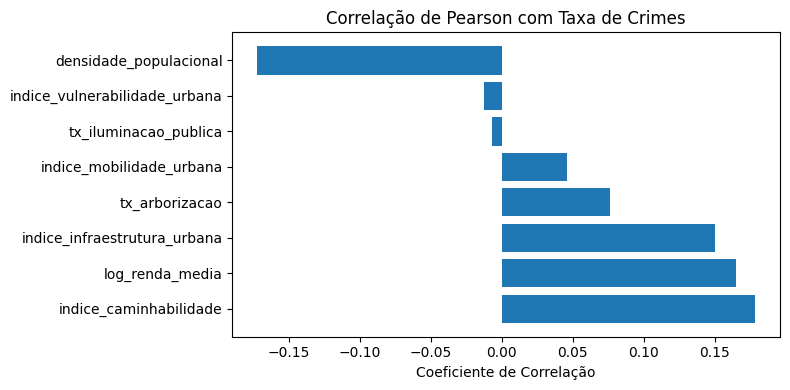

In [33]:
plt.figure(figsize=(8,4))

plt.barh(
    pdf_corr_principal["variavel"],
    pdf_corr_principal["correlacao"]
)

plt.title(
    "Correlação de Pearson com Taxa de Crimes"
)

plt.xlabel("Coeficiente de Correlação")

plt.tight_layout()
plt.show()

## Correlações entre Criminalidade e Características Urbanas

Como etapa preliminar da análise inferencial, foram calculados coeficientes de correlação de Pearson entre a taxa de crimes por 1000 habitantes e variáveis representativas da infraestrutura urbana, mobilidade, renda e características demográficas dos setores censitários.

Os resultados indicaram associações estatísticas positivas, porém de baixa magnitude, entre a criminalidade e algumas características urbanas. As maiores correlações observadas foram para o índice de caminhabilidade (r = 0,178), logaritmo da renda média (r = 0,165) e índice de infraestrutura urbana (r = 0,150).

Em contrapartida, a densidade populacional apresentou correlação negativa (r = -0,172), sugerindo que setores mais densamente ocupados tendem a apresentar menores taxas de roubos e furtos de veículos. Já variáveis tradicionalmente associadas à segurança urbana, como iluminação pública, apresentaram correlação praticamente nula com a criminalidade observada.

De maneira geral, os coeficientes encontrados situam-se abaixo de 0,20 em valor absoluto, indicando associações fracas quando analisadas individualmente. Esse resultado sugere que a ocorrência de roubos e furtos de veículos é influenciada por múltiplos fatores simultaneamente e não pode ser explicada adequadamente por uma única variável urbana isolada.

Diante desse cenário, optou-se pela utilização de modelos de regressão múltipla para avaliar o efeito conjunto das variáveis e controlar possíveis fatores de confusão.

## Modelagem

#### Modelo Inicial Infraestrutura isolada

In [40]:
df_analise_correlacao = (
    df_analise_correlacao
    .withColumn(
        "log_tx_crimes_1000_hab",
        F.log1p(F.col("tx_crimes_1000_hab"))
    )
)

In [41]:
pdf_regressao = (
    df_analise_correlacao
    .select(
        "log_tx_crimes_1000_hab",
        "indice_infraestrutura_urbana"
    )
    .dropna()
    .toPandas()
)

X = pdf_regressao[
    ["indice_infraestrutura_urbana"]
]

X = sm.add_constant(X)

y = pdf_regressao[
    "log_tx_crimes_1000_hab"
]

modelo_1 = sm.OLS(
    y,
    X
).fit()

print(modelo_1.summary())

                              OLS Regression Results                              
Dep. Variable:     log_tx_crimes_1000_hab   R-squared:                       0.045
Model:                                OLS   Adj. R-squared:                  0.045
Method:                     Least Squares   F-statistic:                     7168.
Date:                    Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                            23:11:02   Log-Likelihood:            -1.2614e+05
No. Observations:                  151896   AIC:                         2.523e+05
Df Residuals:                      151894   BIC:                         2.523e+05
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Modelo 1 – Associação entre Infraestrutura Urbana e Criminalidade

O primeiro modelo de regressão teve como objetivo avaliar a relação entre o índice de infraestrutura urbana e a taxa de crimes por 1000 habitantes. Para reduzir a influência da forte assimetria observada na distribuição da criminalidade, utilizou-se como variável dependente o logaritmo natural da taxa de crimes por 1000 habitantes.

O modelo apresentou coeficiente de determinação (R²) de 0,045, indicando que aproximadamente 4,5% da variabilidade observada na criminalidade pode ser explicada exclusivamente pelo índice de infraestrutura urbana.

O coeficiente estimado para a infraestrutura urbana foi positivo (β = 0,982) e estatisticamente significativo (p < 0,001). Esse resultado sugere que setores com melhores condições de infraestrutura tendem a apresentar maiores taxas de roubos e furtos de veículos.

Embora esse resultado possa parecer contraditório à hipótese inicial de que áreas com infraestrutura precária apresentariam maior criminalidade, ele é compatível com a natureza dos crimes analisados. Áreas urbanas mais estruturadas geralmente concentram maior circulação de veículos, maior atividade econômica e veículos de maior valor, aumentando as oportunidades para crimes patrimoniais.

Entretanto, o baixo valor de R² demonstra que a infraestrutura urbana, isoladamente, possui capacidade limitada para explicar a distribuição espacial da criminalidade observada.

#### Modelo Infraestrutura + Renda

In [42]:
pdf_regressao = (
    df_analise_correlacao
    .select(
        "log_tx_crimes_1000_hab",
        "indice_infraestrutura_urbana",
        "log_renda_media"
    )
    .dropna()
    .toPandas()
)
X = pdf_regressao[
    [
        "indice_infraestrutura_urbana",
        "log_renda_media"
    ]
]

X = sm.add_constant(X)

y = pdf_regressao[
    "log_tx_crimes_1000_hab"
]

modelo_2 = sm.OLS(
    y,
    X
).fit()

print(modelo_2.summary())

                              OLS Regression Results                              
Dep. Variable:     log_tx_crimes_1000_hab   R-squared:                       0.082
Model:                                OLS   Adj. R-squared:                  0.082
Method:                     Least Squares   F-statistic:                     6768.
Date:                    Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                            23:11:53   Log-Likelihood:            -1.2313e+05
No. Observations:                  151871   AIC:                         2.463e+05
Df Residuals:                      151868   BIC:                         2.463e+05
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Modelo 2 – Infraestrutura Urbana e Renda

O segundo modelo incorporou o logaritmo da renda média dos responsáveis pelos domicílios como variável de controle, permitindo avaliar se a associação observada entre infraestrutura urbana e criminalidade permanecia após considerar diferenças socioeconômicas entre os setores censitários.

A inclusão da renda aumentou o coeficiente de determinação para R² = 0,082, representando um ganho expressivo em relação ao modelo anterior.

Os resultados indicaram que tanto a infraestrutura urbana (β = 0,430) quanto a renda média (β = 0,198) permaneceram estatisticamente significativas (p < 0,001). Entretanto, observa-se redução substancial do coeficiente associado à infraestrutura quando comparado ao modelo anterior, sugerindo que parte da relação inicialmente observada estava associada à correlação existente entre infraestrutura urbana e renda.

A renda média apresentou associação positiva com a criminalidade, indicando que setores mais ricos tendem a registrar maiores taxas de roubos e furtos de veículos. Esse resultado é consistente com a literatura sobre crimes patrimoniais, que frequentemente identifica áreas de maior renda como potenciais alvos devido à maior concentração de bens de valor econômico elevado.

Os resultados demonstram que fatores socioeconômicos desempenham papel relevante na compreensão da distribuição espacial da criminalidade e não devem ser ignorados em análises exclusivamente baseadas na infraestrutura urbana.

#### Modelo Principal

In [43]:
#### Modelo Principal
pdf_regressao = (
    df_analise_correlacao
    .select(
        "log_tx_crimes_1000_hab",
        "indice_infraestrutura_urbana",
        "indice_mobilidade_urbana",
        "log_renda_media",
        "densidade_populacional"
    )
    .dropna()
    .toPandas()
)

X = pdf_regressao[
    [
        "indice_infraestrutura_urbana",
        "indice_mobilidade_urbana",
        "log_renda_media",
        "densidade_populacional"
    ]
]

X = sm.add_constant(X)

y = pdf_regressao[
    "log_tx_crimes_1000_hab"
]

modelo_3 = sm.OLS(
    y,
    X
).fit()

print(modelo_3.summary())

                              OLS Regression Results                              
Dep. Variable:     log_tx_crimes_1000_hab   R-squared:                       0.123
Model:                                OLS   Adj. R-squared:                  0.123
Method:                     Least Squares   F-statistic:                     5348.
Date:                    Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                            23:12:57   Log-Likelihood:            -1.1961e+05
No. Observations:                  151871   AIC:                         2.392e+05
Df Residuals:                      151866   BIC:                         2.393e+05
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## Modelo 3 – Infraestrutura, Mobilidade, Renda e Densidade Populacional

O terceiro modelo constituiu o modelo principal desta pesquisa, incorporando simultaneamente indicadores de infraestrutura urbana, mobilidade urbana, renda média e densidade populacional.

O modelo apresentou coeficiente de determinação de R² = 0,123, indicando que aproximadamente 12,3% da variabilidade observada na criminalidade é explicada pelo conjunto de variáveis incluídas. Embora a maior parte da variabilidade permaneça associada a fatores não observados, o desempenho obtido é compatível com estudos urbanos e criminológicos que analisam fenômenos espaciais complexos.

Todas as variáveis incluídas apresentaram coeficientes estatisticamente significativos (p < 0,001).

O índice de infraestrutura urbana manteve associação positiva com a criminalidade (β = 0,334), mesmo após o controle dos demais fatores. Esse resultado indica que a relação observada não pode ser atribuída exclusivamente à renda ou à densidade populacional.

O índice de mobilidade urbana também apresentou coeficiente positivo (β = 0,128), sugerindo que áreas com maior acessibilidade e circulação tendem a registrar maiores taxas de roubos e furtos de veículos. Esse resultado pode estar relacionado ao aumento das oportunidades para a ocorrência de crimes em locais com intenso fluxo de pessoas e veículos.

A renda média permaneceu como uma das variáveis mais relevantes do modelo (β = 0,199), reforçando a hipótese de que áreas economicamente mais favorecidas concentram veículos de maior valor e, consequentemente, apresentam maior atratividade para crimes patrimoniais.

Por outro lado, a densidade populacional apresentou associação negativa com a criminalidade (β < 0), indicando que setores mais densamente ocupados tendem a registrar menores taxas de crimes contra veículos. Uma possível interpretação para esse resultado é a presença de maior vigilância informal, ocupação contínua do espaço urbano e menor disponibilidade de áreas isoladas utilizadas para estacionamento.

Os testes de multicolinearidade indicaram valores de VIF inferiores a 2 para todas as variáveis explicativas, demonstrando ausência de problemas relevantes de correlação excessiva entre os preditores e garantindo maior confiabilidade na interpretação dos coeficientes estimados.

Em conjunto, os resultados sugerem que a distribuição espacial dos roubos e furtos de veículos está associada não apenas às características físicas da infraestrutura urbana, mas também a fatores econômicos, demográficos e de mobilidade. Dessa forma, a criminalidade observada no município de São Paulo deve ser compreendida como resultado da interação entre múltiplos elementos da dinâmica urbana, e não como consequência de um único fator isolado.

#### Multicolinearidade

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["variavel"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif

,variavel,VIF
0,const,166.924673
1,indice_infraestrutura_urbana,1.450681
2,indice_mobilidade_urbana,1.060948
3,log_renda_media,1.387308
4,densidade_populacional,1.008125


In [47]:
coeficientes = pd.concat(
    [
        modelo_1.params.rename("Modelo 1"),
        modelo_2.params.rename("Modelo 2"),
        modelo_3.params.rename("Modelo 3")
    ],
    axis=1
)

coeficientes

,Modelo 1,Modelo 2,Modelo 3
const,0.755909,-0.470359,-0.310752
indice_infraestrutura_urbana,0.982279,0.430441,0.334253
log_renda_media,NaN,0.197882,0.199413
indice_mobilidade_urbana,NaN,NaN,0.128009
densidade_populacional,NaN,NaN,-0.000007


In [50]:
pvalues = pd.concat(
    [
        modelo_1.pvalues.rename("Modelo 1"),
        modelo_2.pvalues.rename("Modelo 2"),
        modelo_3.pvalues.rename("Modelo 3")
    ],
    axis=1
)

pvalues

,Modelo 1,Modelo 2,Modelo 3
const,0.0,2.082724e-151,1.923635e-69
indice_infraestrutura_urbana,0.0,1.174418e-225,2.708899e-137
log_renda_media,NaN,0.000000e+00,0.000000e+00
indice_mobilidade_urbana,NaN,NaN,1.933214e-40
densidade_populacional,NaN,NaN,0.000000e+00


In [51]:
tabela_modelos = pd.DataFrame({
    "Modelo": [
        "Infraestrutura",
        "Infraestrutura + Renda",
        "Modelo Principal"
    ],
    "R²": [
        modelo_1.rsquared,
        modelo_2.rsquared,
        modelo_3.rsquared
    ],
    "R² Ajustado": [
        modelo_1.rsquared_adj,
        modelo_2.rsquared_adj,
        modelo_3.rsquared_adj
    ],
    "Observações": [
        int(modelo_1.nobs),
        int(modelo_2.nobs),
        int(modelo_3.nobs)
    ]
})

tabela_modelos

,Modelo,R²,R² Ajustado,Observações
0,Infraestrutura,0.045065,0.045058,151896
1,Infraestrutura + Renda,0.081837,0.081825,151871
2,Modelo Principal,0.123461,0.123437,151871


In [53]:
tabela_modelos = pd.DataFrame({
    "Modelo": [
        "Infraestrutura",
        "Infraestrutura + Renda",
        "Modelo Principal"
    ],
    "R²": [
        modelo_1.rsquared,
        modelo_2.rsquared,
        modelo_3.rsquared
    ],
    "R² Ajustado": [
        modelo_1.rsquared_adj,
        modelo_2.rsquared_adj,
        modelo_3.rsquared_adj
    ],
    "Observações": [
        int(modelo_1.nobs),
        int(modelo_2.nobs),
        int(modelo_3.nobs)
    ]
})

tabela_modelos

,Modelo,R²,R² Ajustado,Observações
0,Infraestrutura,0.045065,0.045058,151896
1,Infraestrutura + Renda,0.081837,0.081825,151871
2,Modelo Principal,0.123461,0.123437,151871


In [54]:
tabela_final = pd.DataFrame({
    "Variável": [
        "Infraestrutura",
        "Renda",
        "Mobilidade",
        "Densidade Pop.",
        "R²"
    ],
    "Modelo 1": [
        round(modelo_1.params["indice_infraestrutura_urbana"], 3),
        "-",
        "-",
        "-",
        round(modelo_1.rsquared, 3)
    ],
    "Modelo 2": [
        round(modelo_2.params["indice_infraestrutura_urbana"], 3),
        round(modelo_2.params["log_renda_media"], 3),
        "-",
        "-",
        round(modelo_2.rsquared, 3)
    ],
    "Modelo 3": [
        round(modelo_3.params["indice_infraestrutura_urbana"], 3),
        round(modelo_3.params["log_renda_media"], 3),
        round(modelo_3.params["indice_mobilidade_urbana"], 3),
        f"{modelo_3.params['densidade_populacional']:.2e}",
        round(modelo_3.rsquared, 3)
    ]
})

tabela_final

,Variável,Modelo 1,Modelo 2,Modelo 3
0,Infraestrutura,0.982,0.43,0.334
1,Renda,-,0.198,0.199
2,Mobilidade,-,-,0.128
3,Densidade Pop.,-,-,-6.83e-06
4,R²,0.045,0.082,0.123


## Interpretação dos Modelos de Regressão

A Tabela Final apresenta os coeficientes estimados para os três modelos de regressão desenvolvidos neste estudo, bem como seus respectivos coeficientes de determinação (R²).

O **Modelo 1** considera apenas o índice de infraestrutura urbana como variável explicativa da criminalidade. O coeficiente positivo encontrado (β = 0,982) indica que setores com melhores condições de infraestrutura tendem a apresentar maiores taxas de roubos e furtos de veículos. Entretanto, o modelo apresenta baixo poder explicativo (R² = 0,045), indicando que apenas 4,5% da variação observada na criminalidade pode ser explicada pela infraestrutura urbana isoladamente.

No **Modelo 2**, foi incluída a variável de renda média dos responsáveis pelos domicílios. Observa-se redução do coeficiente associado à infraestrutura (de 0,982 para 0,430), sugerindo que parte da associação observada no primeiro modelo era compartilhada com características socioeconômicas dos setores. Ao mesmo tempo, a renda apresentou coeficiente positivo (β = 0,198), indicando que áreas com maior renda tendem a registrar maiores taxas de roubos e furtos de veículos. A inclusão dessa variável elevou o coeficiente de determinação para R² = 0,082, aumentando a capacidade explicativa do modelo.

O **Modelo 3**, considerado o modelo principal da pesquisa, incorpora simultaneamente indicadores de infraestrutura urbana, mobilidade urbana, renda média e densidade populacional. Esse modelo apresentou o maior poder explicativo (R² = 0,123), indicando que aproximadamente 12,3% da variabilidade observada na criminalidade é explicada pelo conjunto das variáveis analisadas.

A análise dos coeficientes permite observar que:

- O **índice de infraestrutura urbana** permaneceu positivo e estatisticamente significativo (β = 0,334), mesmo após o controle das demais variáveis. Isso sugere que a associação observada não é explicada exclusivamente pela renda ou pela densidade populacional.
- O **índice de mobilidade urbana** apresentou coeficiente positivo (β = 0,128), indicando que áreas com maior acessibilidade e circulação de pessoas tendem a registrar maiores taxas de crimes contra veículos.
- A **renda média** manteve associação positiva (β = 0,199), reforçando a hipótese de que regiões economicamente mais favorecidas concentram veículos de maior valor e, consequentemente, tornam-se alvos mais atrativos para crimes patrimoniais.
- A **densidade populacional** apresentou coeficiente negativo (β < 0), sugerindo que setores mais densamente ocupados tendem a registrar menores taxas de roubos e furtos de veículos. Uma possível explicação é a maior presença de vigilância informal e ocupação contínua do espaço urbano.

A comparação entre os modelos demonstra que a criminalidade não pode ser explicada adequadamente por um único fator isolado. Os resultados sugerem que roubos e furtos de veículos estão associados à combinação de características urbanas, econômicas e demográficas que, em conjunto, influenciam a distribuição espacial dos eventos criminais.

Por fim, embora os coeficientes de determinação obtidos sejam relativamente modestos, esse resultado é esperado em estudos sobre fenômenos urbanos complexos. A ocorrência de crimes é influenciada por diversos fatores não observados nesta pesquisa, como características da frota circulante, fluxo diário de pessoas, presença policial, dinâmica econômica local e aspectos comportamentais da população. Dessa forma, os modelos estimados devem ser interpretados como instrumentos para identificar associações estatísticas relevantes, e não como explicações completas da criminalidade observada.

## Considerações sobre o Poder Explicativo dos Modelos

Os modelos de regressão estimados apresentaram coeficientes de determinação (R²) variando entre 0,045 e 0,123. Em termos práticos, isso significa que as variáveis analisadas explicam entre 4,5% e 12,3% da variabilidade observada nas taxas de roubos e furtos de veículos entre os setores censitários do município de São Paulo.

À primeira vista, esses valores podem parecer modestos. Entretanto, sua interpretação deve considerar a natureza do fenômeno estudado. A criminalidade constitui um processo social complexo, influenciado simultaneamente por fatores econômicos, demográficos, territoriais, comportamentais e institucionais que não são completamente observáveis ou mensuráveis por meio dos dados disponíveis.

Entre os fatores não contemplados neste estudo estão, por exemplo, a quantidade de veículos circulando em cada região, o valor médio da frota, a intensidade dos fluxos pendulares de trabalho e estudo, a proximidade de grandes corredores viários, a presença policial, sistemas de monitoramento urbano, características do uso e ocupação do solo e outros elementos associados à dinâmica cotidiana da cidade.

Dessa forma, é esperado que modelos construídos exclusivamente com variáveis censitárias e indicadores de infraestrutura urbana apresentem coeficientes de determinação relativamente inferiores aos observados em áreas como engenharia, física ou ciências naturais, onde os fenômenos estudados tendem a ser mais determinísticos e controláveis.

Apesar do poder explicativo moderado, os modelos estimados apresentaram resultados estatisticamente robustos. Todas as variáveis incluídas no modelo principal apresentaram coeficientes estatisticamente significativos (p < 0,001), indicando que as associações observadas dificilmente ocorreram ao acaso. Além disso, os testes de multicolinearidade demonstraram ausência de problemas relevantes entre as variáveis explicativas, reforçando a confiabilidade dos coeficientes estimados.

Observa-se também uma evolução consistente do poder explicativo entre os modelos. O R² aumentou de 0,045 no modelo contendo apenas infraestrutura urbana para 0,123 no modelo completo, demonstrando que a incorporação de variáveis socioeconômicas, demográficas e de mobilidade contribui para uma compreensão mais abrangente da distribuição espacial da criminalidade.

Portanto, os resultados obtidos devem ser interpretados não como um modelo de previsão exata dos roubos e furtos de veículos, mas como evidência empírica da existência de associações estatisticamente significativas entre características urbanas dos setores censitários e a incidência criminal observada. Nesse contexto, os coeficientes de determinação encontrados são compatíveis com a literatura de estudos urbanos, geográficos e criminológicos que investigam fenômenos sociais complexos em escala territorial.

# Variáveis Utilizadas na Análise

A análise estatística foi realizada utilizando indicadores demográficos, socioeconômicos e de infraestrutura urbana construídos a partir dos dados do Censo Demográfico 2022 do IBGE em nível de setor censitário. As variáveis foram organizadas em quatro grupos principais: características demográficas, infraestrutura urbana, indicadores socioeconômicos e índices compostos.

## Variável Dependente

A variável dependente utilizada nos modelos de correlação e regressão foi a taxa de roubos e furtos de veículos por 1000 habitantes.

### Taxa de Crimes por 1000 Habitantes

Representa a quantidade de roubos e furtos de veículos registrada em determinado setor censitário, padronizada pela população residente.

\[
Taxa\ de\ Crimes = \frac{Quantidade\ de\ Crimes}{População} \times 1000
\]

Com o objetivo de reduzir a assimetria da distribuição observada nos dados, também foi utilizada uma transformação logarítmica da variável:

\[
\log(1 + Taxa\ de\ Crimes)
\]

---

## Variáveis Demográficas

### Densidade Populacional

Quantidade de habitantes por quilômetro quadrado.

\[
\frac{População}{Área\ do\ Setor}
\]

### Densidade de Domicílios

Quantidade de domicílios por quilômetro quadrado.

\[
\frac{Domicílios}{Área\ do\ Setor}
\]

### Taxa de Domicílios Ocupados

Proporção de domicílios ocupados em relação ao total de domicílios do setor.

### Taxa de Domicílios Vagos

Proporção de domicílios vagos em relação ao total de domicílios do setor.

### Média de Moradores por Domicílio

Número médio de moradores nos domicílios particulares ocupados.

---

## Variáveis de Infraestrutura Urbana

Todas as variáveis foram calculadas como proporções entre 0 e 1.

### Taxa de Via Pavimentada

Proporção de domicílios localizados em vias pavimentadas.

### Taxa de Bueiros

Proporção de domicílios localizados em vias que possuem bueiros ou bocas de lobo.

### Taxa de Iluminação Pública

Proporção de domicílios localizados em vias com iluminação pública.

### Taxa de Ponto de Ônibus

Proporção de domicílios localizados próximos a pontos de transporte coletivo.

### Taxa de Ciclovias

Proporção de domicílios localizados em vias com infraestrutura cicloviária.

### Taxa de Calçadas

Proporção de domicílios localizados em vias que possuem calçadas.

### Taxa de Obstáculos em Calçadas

Proporção de domicílios localizados em vias cujas calçadas apresentam obstáculos à circulação.

### Taxa de Rampas para Cadeirantes

Proporção de domicílios localizados em vias que possuem rampas de acessibilidade.

### Taxa de Arborização

Proporção de domicílios localizados em vias que apresentam pelo menos uma árvore.

### Índice Ponderado de Arborização

Indicador que considera não apenas a presença de árvores, mas também sua intensidade. Setores com maior quantidade de árvores recebem pontuação superior.

---

## Variáveis Socioeconômicas

### Logaritmo da Renda Média

Transformação logarítmica da renda nominal média dos responsáveis pelos domicílios.

A transformação foi utilizada para reduzir a influência de valores extremos e aproximar a distribuição da normalidade.

### Logaritmo da Renda Mediana

Transformação logarítmica da renda nominal mediana dos responsáveis pelos domicílios.

### Renda Média por Morador

Razão entre a renda média dos responsáveis e o número médio de moradores por domicílio.

### Renda Mediana por Morador

Razão entre a renda mediana dos responsáveis e o número médio de moradores por domicílio.

### Densidade de Renda Média

Renda média distribuída por quilômetro quadrado.

### Densidade de Renda Mediana

Renda mediana distribuída por quilômetro quadrado.

---

## Índices Compostos

Com o objetivo de sintetizar múltiplos indicadores em medidas únicas e facilitar a interpretação dos resultados, foram construídos índices compostos por meio da média simples de variáveis padronizadas.

### Índice de Infraestrutura Urbana

Representa o nível geral de infraestrutura disponível no setor censitário.

Foi calculado pela média das seguintes variáveis:

- Taxa de vias pavimentadas;
- Taxa de bueiros;
- Taxa de iluminação pública;
- Taxa de calçadas;
- Taxa de rampas para cadeirantes;
- Taxa de arborização.

Valores mais próximos de 1 indicam melhor infraestrutura urbana.

### Índice de Mobilidade Urbana

Representa a disponibilidade de infraestrutura associada à mobilidade sustentável.

Foi calculado pela média de:

- Taxa de pontos de ônibus;
- Taxa de ciclovias.

Valores mais elevados indicam melhores condições de mobilidade urbana.

### Índice de Caminhabilidade

Representa a qualidade da circulação de pedestres no espaço urbano.

Foi calculado pela média de:

- Taxa de calçadas;
- Taxa de rampas para cadeirantes;
- Ausência de obstáculos nas calçadas.

Valores elevados indicam maior facilidade de deslocamento a pé.

### Índice de Vulnerabilidade Urbana

Representa condições urbanas potencialmente desfavoráveis.

Foi calculado a partir de:

- Taxa de domicílios vagos;
- Ausência de iluminação pública;
- Ausência de pavimentação;
- Ausência de calçadas;
- Ausência de bueiros.

Valores mais elevados indicam maior vulnerabilidade urbana e menor disponibilidade de infraestrutura básica.